# 5 - FSK SDR Demod

SDR-Capture/Replay , danach FSK-Demodulation analog zu `4-FM-IQ-demod.ipynb`.

Ablauf:
1. IQ-Samples vom RTL-SDR einlesen (oder Replay/Fallback)
2. Trägerlage aus Spektrum schätzen
3. IQ-Rekonstruktion via komplexem LO und FIR-Tiefpass hoher Ordnung (scipy.signal)
4. FM-Demodulation per Phasendifferenz
5. Augendiagramm und Amplituden-Histogramm
6. Audio-Feedback

## Parameter und Imports

### ToDo: gegebenenfalls center frequency und gain für den SDR anpassen!

In [71]:
import os
import json
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt
from IPython.display import Audio, display
from scipy.signal import firwin

# SDR / Replay 
USE_REPLAY = True
REPLAY_FILE = Path('recordings/fsk_sdr_replay.json')
CENTER_FREQ_HZ = 434.1e6
SAMPLE_RATE_HZ = 0.256e6    # Beachte, dass wir hier nicht, so wie meist, eine Samplerate von 2.048 Msps verwenden!
GAIN_DB = 40.0              # das Gain-Setting des SDR muss eventuell an die Laborbedingungen angepasst werden !
TOTAL_SAMPLES = 262_144 * 4

total_sampling_duration = TOTAL_SAMPLES / SAMPLE_RATE_HZ

# Spektrum
N_fft = 16384 * 4
USE_FFT_WINDOW = True
FFT_WINDOW_KIND = 'hann'  # 'hann' | 'hamming' | 'rect'


# Demod / Plot
t_plot_ms = 6.0

# Audio
fs_audio = 48_000
start_s = 0.0
duration_s = max(5.0,total_sampling_duration)

print(f'Total Sampling Duration={total_sampling_duration} sec')

Total Sampling Duration=4.096 sec


## 1) Hilfsfunktionen (Capture/Replay/Fallback)

In [72]:
def _window(n: int, use_window: bool = True, kind: str = 'hann') -> np.ndarray:
    if not use_window:
        return np.ones(n)
    if kind == 'hann':
        return np.hanning(n)
    if kind == 'hamming':
        return np.hamming(n)
    return np.ones(n)


def save_replay_iq(path: Path, iq: np.ndarray, fs_hz: float):
    path.parent.mkdir(parents=True, exist_ok=True)
    data = {
        'fs_hz': float(fs_hz),
        'iq_real': np.real(iq).tolist(),
        'iq_imag': np.imag(iq).tolist(),
    }
    path.write_text(json.dumps(data), encoding='utf-8')


def load_replay_iq(path: Path):
    data = json.loads(path.read_text(encoding='utf-8'))
    iq = np.array(data['iq_real'], dtype=np.float32) + 1j*np.array(data['iq_imag'], dtype=np.float32)
    fs_hz = float(data.get('fs_hz', SAMPLE_RATE_HZ))
    return iq.astype(np.complex64), fs_hz


def setup_rtlsdr_driver_path() -> None:
    """Sucht rtl-sdr-driver im Workspace und ergänzt PATH/DLL-Suchpfad."""
    driver_dir = None
    for p in [Path.cwd()] + list(Path.cwd().parents):
        cand = p / 'rtl-sdr-driver'
        if cand.exists() and (cand / 'librtlsdr.dll').exists():
            driver_dir = cand
            break

    if driver_dir is not None:
        os.environ['PATH'] = str(driver_dir) + os.pathsep + os.environ.get('PATH', '')
        try:
            os.add_dll_directory(str(driver_dir))
        except Exception:
            pass
        print('RTL-SDR Treiber gefunden:', driver_dir)
    else:
        print('Hinweis: rtl-sdr-driver nicht gefunden, ggf. Fallback-Signal wird genutzt.')


def capture_rtlsdr(center_hz: float, fs_hz: float, gain_db: float, total_samples: int):
    setup_rtlsdr_driver_path()

    try:
        from rtlsdr import RtlSdr
    except Exception as ex:
        raise RuntimeError(f'rtlsdr nicht verfügbar: {ex}')

    sdr = RtlSdr()
    sdr.sample_rate = fs_hz
    sdr.center_freq = center_hz
    sdr.gain = gain_db
    iq = sdr.read_samples(total_samples).astype(np.complex64)
    iq = sdr.read_samples(total_samples).astype(np.complex64)
    sdr.close()
    return iq


def synthetic_fm_fallback(fs_hz: float, total_samples: int):
    t = np.arange(total_samples) / fs_hz
    f_if = 35_000.0
    f_m = 1_000.0
    delta_f = 3_000.0
    u = np.cos(2*np.pi*f_m*t)
    int_u = np.cumsum(u) / fs_hz
    phase = 2*np.pi*f_if*t + 2*np.pi*delta_f*int_u
    z = np.exp(1j*phase)
    return z.astype(np.complex64)

## 2) Capture oder Replay laden

In [73]:
if USE_REPLAY and REPLAY_FILE.exists():
    iq, fs = load_replay_iq(REPLAY_FILE)
    print('Replay-IQ geladen:', REPLAY_FILE)
else:
    try:
        iq = capture_rtlsdr(CENTER_FREQ_HZ, SAMPLE_RATE_HZ, GAIN_DB, TOTAL_SAMPLES)
        fs = float(SAMPLE_RATE_HZ)
        save_replay_iq(REPLAY_FILE, iq, fs)
        print('Replay-IQ gespeichert:', REPLAY_FILE)
    except Exception as ex:
        print('RTL-SDR nicht verfügbar, nutze synthetischen Fallback:', ex)
        iq = synthetic_fm_fallback(SAMPLE_RATE_HZ, TOTAL_SAMPLES)
        fs = float(SAMPLE_RATE_HZ)
        save_replay_iq(REPLAY_FILE, iq, fs)
        print('Fallback-IQ gespeichert:', REPLAY_FILE)

if iq.size < TOTAL_SAMPLES:
    raise RuntimeError(f'Zu wenige Samples: {iq.size} < {TOTAL_SAMPLES}')
iq = iq[:TOTAL_SAMPLES].astype(np.complex64)

N = len(iq)
t = np.arange(N) / fs
n_plot = min(N, int(t_plot_ms * 1e-3 * fs))
print(f'Samples: {N}, fs={fs:.1f} Hz')

Replay-IQ geladen: recordings\fsk_sdr_replay.json
Samples: 1048576, fs=256000.0 Hz


## 3) Spektrum des eingelesenen komplexen IQ-Signals und Träger-/LO-Schätzung

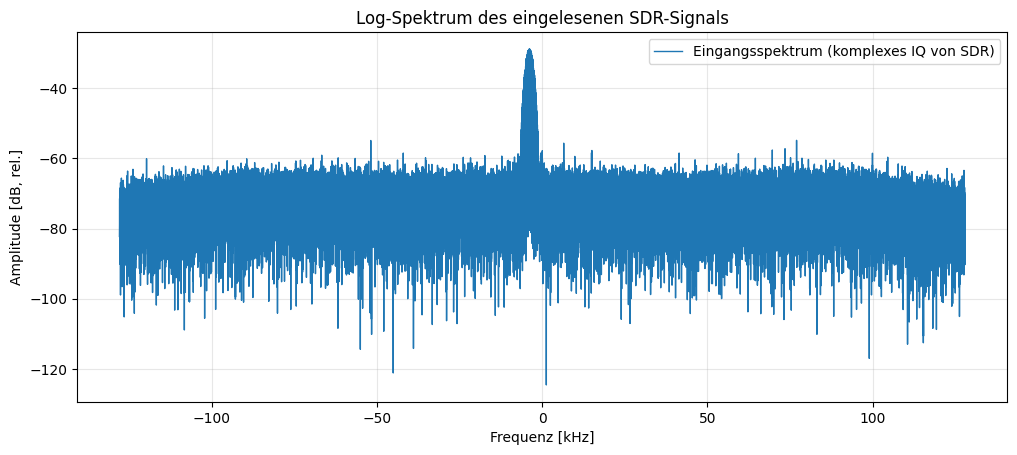

In [74]:
x_pad = np.zeros(N_fft, dtype=np.complex128)    # falls Signallänge < FFT-Länge, padding mit Null
x_pad[:min(N, N_fft)] = iq[:min(N, N_fft)]
w = _window(N_fft, USE_FFT_WINDOW, FFT_WINDOW_KIND)
cg = np.mean(w)                                 # gain compensation der window-function
S = np.fft.fftshift(np.fft.fft(x_pad * w, n=N_fft))
f_spec = np.fft.fftshift(np.fft.fftfreq(N_fft, d=1/fs))
A = np.abs(S) / max(N_fft * cg, 1e-12)
S_db = 20*np.log10(np.maximum(A, 1e-12))   # log-Spektrum

plt.figure(figsize=(12, 4.8))
plt.plot(f_spec/1e3, S_db, lw=1.0, label='Eingangsspektrum (komplexes IQ von SDR)')
plt.title('Log-Spektrum des eingelesenen SDR-Signals')
plt.xlabel('Frequenz [kHz]')
plt.ylabel('Amplitude [dB, rel.]')
plt.grid(alpha=0.3)
plt.legend()
plt.show()



## ToDo: Schätzung der Trägerfrequenz

- Aus dem Spektrum des empfangenen Signals soll dessen Trägerfrequenz geschätzt werden, damit wir mit dem LO dieses Signals möglichst in die Nähe von Null Hertz verschieben können.


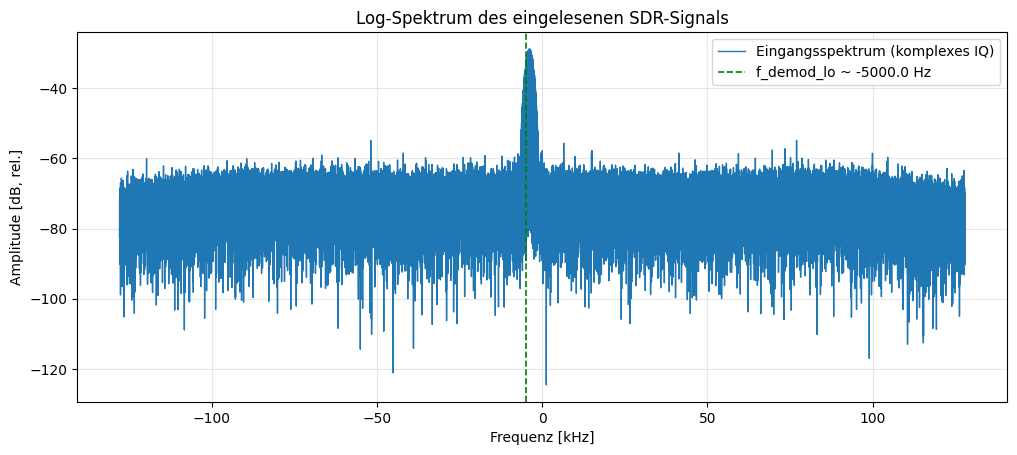

Geschätzte Demod-LO-Frequenz: -5000.0 Hz


In [75]:

# Trage HIER eine Schätzung der Trägerfrequenz ein
f_demod_lo = -5000.0

plt.figure(figsize=(12, 4.8))
plt.plot(f_spec/1e3, S_db, lw=1.0, label='Eingangsspektrum (komplexes IQ)')
plt.axvline(f_demod_lo/1e3, color='g', ls='--', lw=1.2, label=f'f_demod_lo ~ {f_demod_lo:.1f} Hz')
plt.title('Log-Spektrum des eingelesenen SDR-Signals')
plt.xlabel('Frequenz [kHz]')
plt.ylabel('Amplitude [dB, rel.]')
plt.grid(alpha=0.3)
plt.legend()
plt.show()

print(f'Geschätzte Demod-LO-Frequenz: {f_demod_lo:.1f} Hz')

## 4) Komplexes Heruntermischen (Downconversion)

$$u[n] = iq[n]\cdot e^{-j2\pi f_{demod}n/f_s}$$


In [76]:
t = np.arange(len(iq)) / fs
lo_cx = np.exp(-1j * 2*np.pi * f_demod_lo * t)
u_mix = iq * lo_cx

I_raw = np.real(u_mix).astype(np.float64)
Q_raw = np.imag(u_mix).astype(np.float64)

print(f'Downconversion fertig: f_demod_lo={f_demod_lo:.1f} Hz, Samples={len(u_mix)}')


Downconversion fertig: f_demod_lo=-5000.0 Hz, Samples=1048576


## 4a) Spektrum des heruntergemischten Signals (vor FIR)


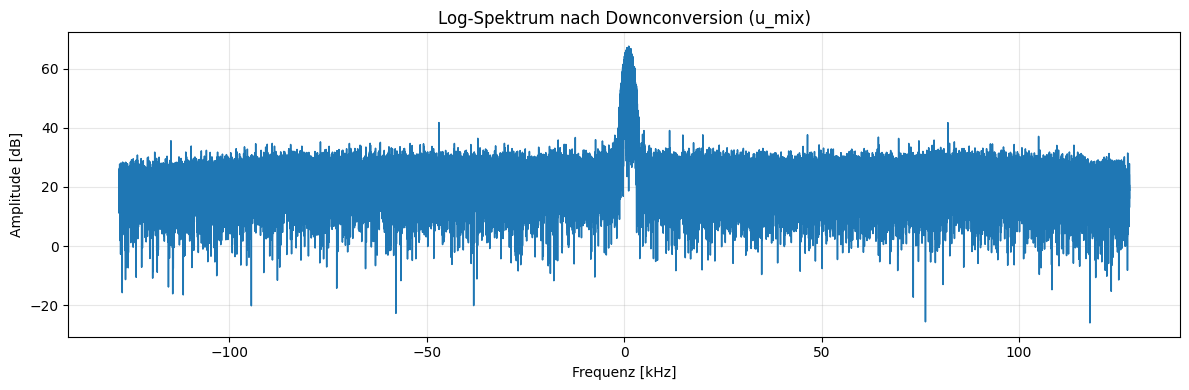

In [77]:
x_mix = np.zeros(N_fft, dtype=np.complex128)
x_mix[:min(len(u_mix), N_fft)] = u_mix[:min(len(u_mix), N_fft)]
X_mix = np.fft.fftshift(np.fft.fft(x_mix))
f_axis_mix = np.fft.fftshift(np.fft.fftfreq(N_fft, 1/fs))
A_mix_db = 20*np.log10(np.maximum(np.abs(X_mix), 1e-12))

plt.figure(figsize=(12, 4))
plt.plot(f_axis_mix/1e3, A_mix_db, lw=1.1)
plt.title('Log-Spektrum nach Downconversion (u_mix)')
plt.xlabel('Frequenz [kHz]')
plt.ylabel('Amplitude [dB]')
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()


## 4b) FIR-Tiefpass und Spektrum des gefilterten Signals

$$z_{bb}[n]=(u*h_{FIR})[n]$$

Konfigurierbar über Tap-Anzahl, Grenzfrequenz, Fensterfunktion und Faltungsmodus.

### ToDo: 
- die FIR cutoff frequenz soll im Bereich bis 50 kHz variiert werden, um den Einfluss dieser Filterbandbreite auf das erzielte SNR nach der Demodulation zu untersuchen.
- finde die optimale Filterbandbreite für das beste erzielbare SNR nach der Demodulation !


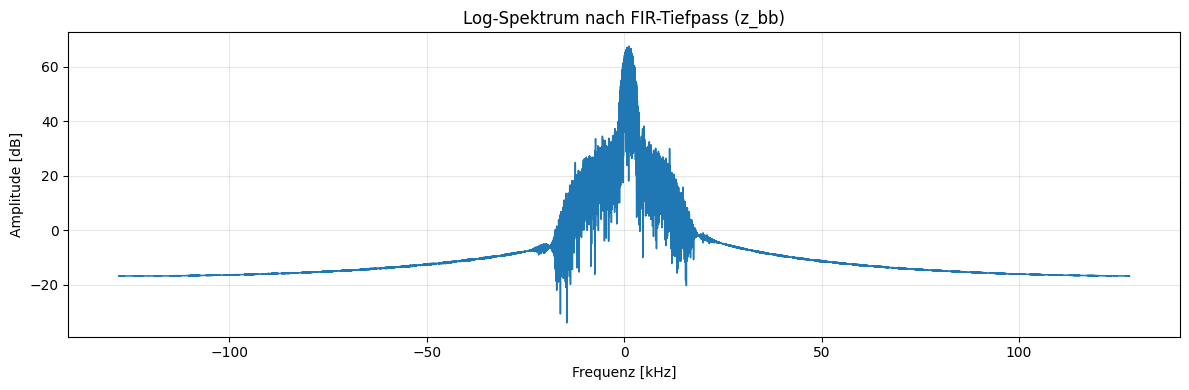

FIR-Tiefpass: taps=51, cutoff=10000.0 Hz, window=hamming, mode=same


In [78]:
# FIR-Parameter (konfigurierbar)
FIR_NUM_TAPS = 51                # Tap-Länge (ungerade empfohlen)
FIR_CUTOFF_HZ = 10_000.0           # Grenzfrequenz [Hz] soll optimiert werden hinsichtlich SNR nach der Demodulation
FIR_WINDOW = 'hamming'            # z.B. 'hann', 'hamming', 'blackman'
FIR_APPLY_MODE = 'same'           # 'full' | 'same' | 'valid'

nyq = 0.5 * fs
cutoff_norm = min(max(FIR_CUTOFF_HZ / nyq, 1e-6), 0.999)
num_taps = int(FIR_NUM_TAPS)
if num_taps % 2 == 0:
    num_taps += 1

h_fir = firwin(num_taps, cutoff=cutoff_norm, window=FIR_WINDOW, pass_zero='lowpass')
I_bb = np.convolve(I_raw, h_fir, mode=FIR_APPLY_MODE)
Q_bb = np.convolve(Q_raw, h_fir, mode=FIR_APPLY_MODE)
z_bb = I_bb + 1j * Q_bb

x_f = np.zeros(N_fft, dtype=np.complex128)
x_f[:min(len(z_bb), N_fft)] = z_bb[:min(len(z_bb), N_fft)]
X_f = np.fft.fftshift(np.fft.fft(x_f))
f_axis_f = np.fft.fftshift(np.fft.fftfreq(N_fft, 1/fs))
A_f_db = 20*np.log10(np.maximum(np.abs(X_f), 1e-12))

plt.figure(figsize=(12, 4))
plt.plot(f_axis_f/1e3, A_f_db, lw=1.1)
plt.title('Log-Spektrum nach FIR-Tiefpass (z_bb)')
plt.xlabel('Frequenz [kHz]')
plt.ylabel('Amplitude [dB]')
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

print(
    f'FIR-Tiefpass: taps={num_taps}, cutoff={FIR_CUTOFF_HZ:.1f} Hz, ' +
    f'window={FIR_WINDOW}, mode={FIR_APPLY_MODE}'
)


## 4b1) FIR-Frequenzgang $|H(f)|$

Darstellung des Amplitudengangs des entworfenen FIR-Tiefpasses in dB.


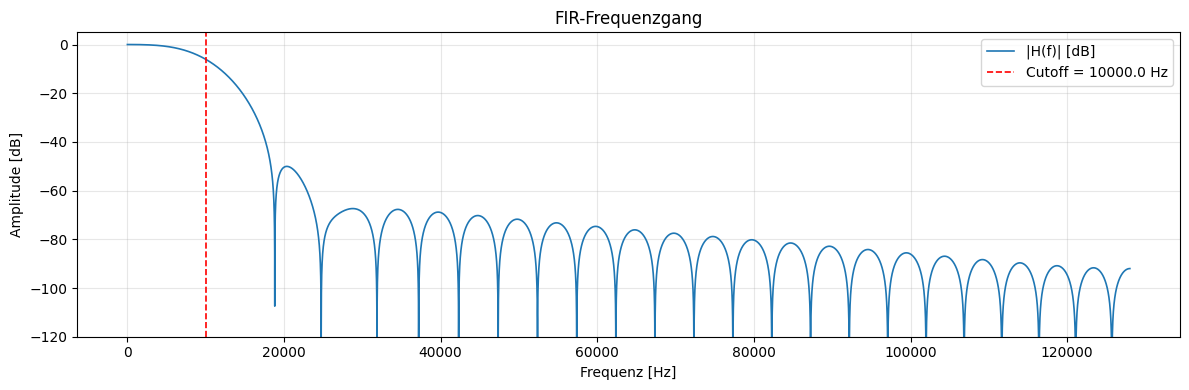

In [79]:
# Frequenzgang des FIR-Filters (ohne Zusatzfunktionen)
N_resp = max(4096, N_fft)
H = np.fft.rfft(h_fir, n=N_resp)
f_resp = np.fft.rfftfreq(N_resp, d=1/fs)
H_db = 20*np.log10(np.maximum(np.abs(H), 1e-12))

plt.figure(figsize=(12, 4))
plt.plot(f_resp, H_db, lw=1.2, label='|H(f)| [dB]')
plt.axvline(FIR_CUTOFF_HZ, color='r', ls='--', lw=1.2, label=f'Cutoff = {FIR_CUTOFF_HZ:.1f} Hz')
plt.title('FIR-Frequenzgang')
plt.xlabel('Frequenz [Hz]')
plt.ylabel('Amplitude [dB]')
plt.ylim(-120, 5)
plt.grid(alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()


## 4c) Zeitbereichsplots für I- und Q-Signal (nach FIR)


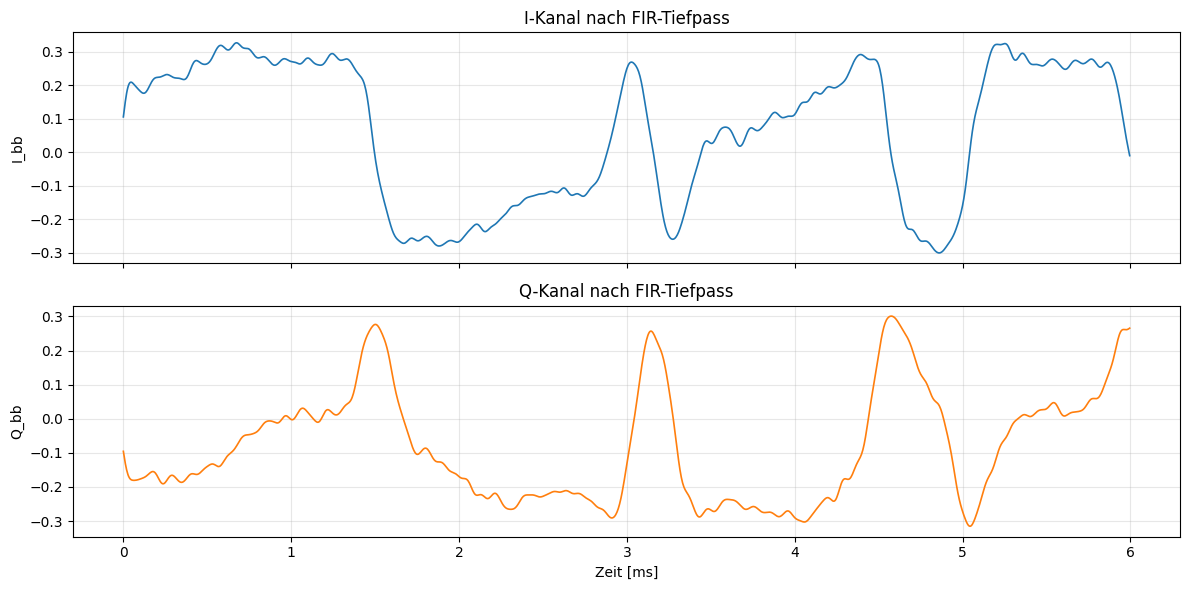

In [80]:
plot_ms = float(globals().get('TIME_PLOT_MS', globals().get('t_plot_ms', 6.0)))
n_plot = min(len(I_bb), int(plot_ms * 1e-3 * fs))
fig, ax = plt.subplots(2, 1, figsize=(12, 6), sharex=True)
ax[0].plot(t[:n_plot]*1e3, I_bb[:n_plot], lw=1.2)
ax[0].set_title('I-Kanal nach FIR-Tiefpass')
ax[0].set_ylabel('I_bb')
ax[0].grid(alpha=0.3)

ax[1].plot(t[:n_plot]*1e3, Q_bb[:n_plot], lw=1.2, color="tab:orange")
ax[1].set_title('Q-Kanal nach FIR-Tiefpass')
ax[1].set_xlabel('Zeit [ms]')
ax[1].set_ylabel('Q_bb')
ax[1].grid(alpha=0.3)
plt.tight_layout()
plt.show()


## 5) FM bzw. FSK-Demodulation

$$d[n]=z_{bb}[n]\,z_{bb}^*[n-1],\; y[n]=\angle\{d[n]\}$$

In [81]:
d = z_bb[1:] * np.conj(z_bb[:-1])
fm_disc = np.concatenate(([0.0], np.angle(d)))

demod_ref_win = int(globals().get('num_taps', globals().get('FIR_NUM_TAPS', 21)))
N_win_demod = max(3, int(np.round(0.35 * demod_ref_win)))
if N_win_demod % 2 == 0:
    N_win_demod += 1
h_demod = np.ones(N_win_demod) / N_win_demod
u_demod = np.convolve(fm_disc, h_demod, mode='same')
u_demod = u_demod - np.mean(u_demod)

print(f'Demod-Tiefpassfenster N_win_demod = {N_win_demod} (Referenzfenster={demod_ref_win})')

Demod-Tiefpassfenster N_win_demod = 19 (Referenzfenster=51)


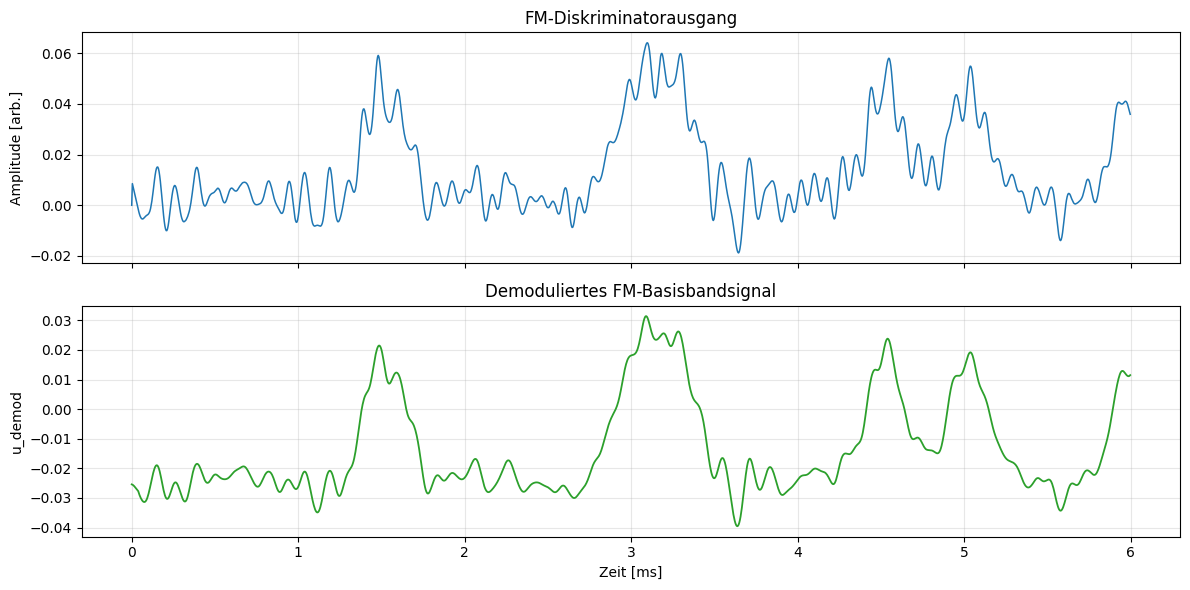

In [82]:
fig, ax = plt.subplots(2, 1, figsize=(12, 6), sharex=True)
ax[0].plot(t[:n_plot]*1e3, fm_disc[:n_plot], lw=1.1)
ax[0].set_title('FM-Diskriminatorausgang')
ax[0].set_ylabel('Amplitude [arb.]')
ax[0].grid(alpha=0.3)

ax[1].plot(t[:n_plot]*1e3, u_demod[:n_plot], lw=1.3, color='tab:green')
ax[1].set_title('Demoduliertes FM-Basisbandsignal')
ax[1].set_xlabel('Zeit [ms]')
ax[1].set_ylabel('u_demod')
ax[1].grid(alpha=0.3)
plt.tight_layout()
plt.show()

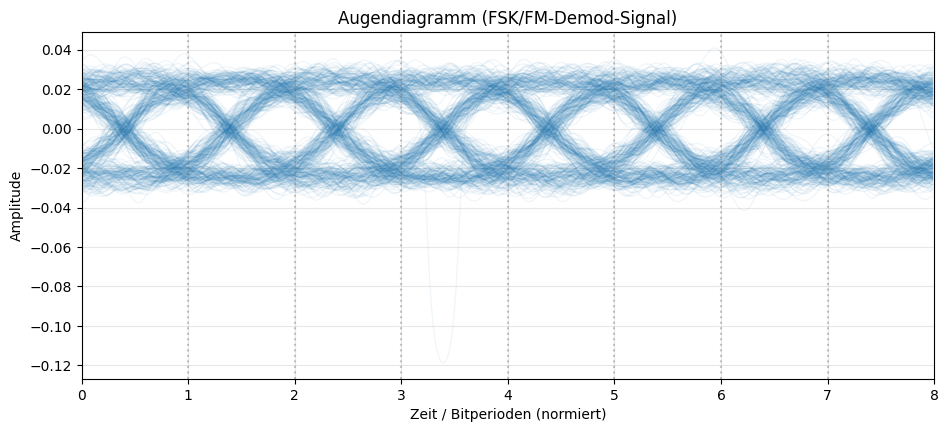

Sample Rate=256000.0,  SAMPLES_PER_BIT=64, NUM_BITS_IN_EYE_PLOT=8, implizite Bitrate ~ 4000.0 bit/s


In [83]:
# Augendiagramm nach Demodulation (u_demod)
from lib.eye_diagram import plot_eye_diagram

# === Experimentierparameter ===
# Bitlaenge in Samples: entweder direkt (z. B. SAMPLES_PER_BIT = 2048) oder aus Bitrate:
BITRATE_ASSUMED_HZ = 4000.0  # diese Bitrate ist fix vorgegeben, d.h. es wird ein entsprechendes live-Signal im Labor gesendet!
SAMPLES_PER_BIT = max(1, int(round(fs / BITRATE_ASSUMED_HZ)))
NUM_BITS_IN_EYE_PLOT = 8   # horizontale Symbolperioden im Plot ("Augen" / Bits sichtbar)
EYE_START_OFFSET = 0       # Fenster-Raster: bei Bedarf 0 .. SAMPLES_PER_BIT-1 durchprobieren (Raster zu Bitgrenzen)
EYE_MAX_TRACES = 450

plot_eye_diagram(
    u_demod,
    samples_per_bit=SAMPLES_PER_BIT,
    num_bits_visible=NUM_BITS_IN_EYE_PLOT,
    start_offset=EYE_START_OFFSET,
    max_traces=EYE_MAX_TRACES,
    title="Augendiagramm (FSK/FM-Demod-Signal)",
)
plt.show()

print(
    f"Sample Rate={fs},  "
    f"SAMPLES_PER_BIT={SAMPLES_PER_BIT}, NUM_BITS_IN_EYE_PLOT={NUM_BITS_IN_EYE_PLOT}, "
    f"implizite Bitrate ~ {fs / SAMPLES_PER_BIT:.1f} bit/s"
)


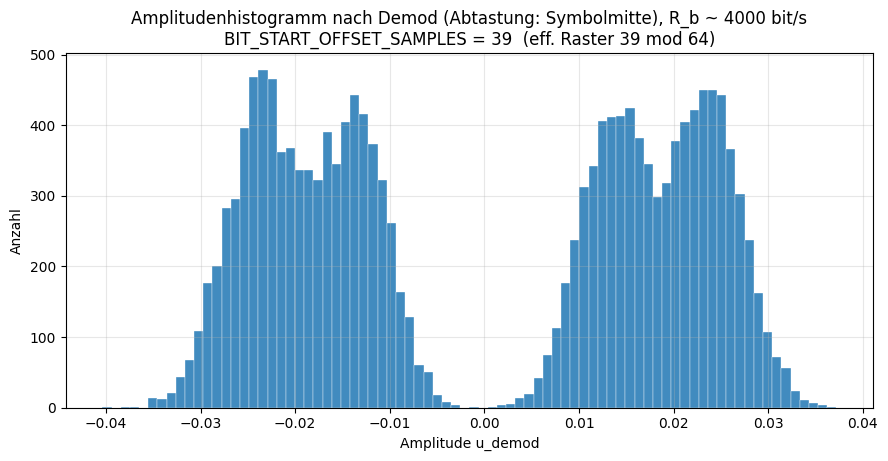

IntSlider(value=20, description='Bit-Start-Offset [Samples]', layout=Layout(width='520px'), max=63)

HIST_SYMBOL_CENTER_ONLY=True, N=16384, SAMPLES_PER_BIT=64, BIT_START_OFFSET_SAMPLES=20


In [87]:
# Amplitudenhistogramm des demodulierten Signals (u_demod)
# True: nur Samples in Bitmitte (eine Stuetzstelle pro Symbol) -> klarere Peak-Struktur
# False: alle Samples -> zusaetzlich Uebergaenge/Ripple, Histogramm breiter
BITRATE_ASSUMED_HZ = 4000.0
SAMPLES_PER_BIT = max(1, int(round(fs / BITRATE_ASSUMED_HZ)))
HIST_SYMBOL_CENTER_ONLY = True

# Bit-Raster relativ zu u_demod[0]: Sample-Index, an dem Bit 0 beginnt (SDR-Start oft nicht
# bit-synchron). Wirklich relevant ist die Phase innerhalb einer Bitlaenge -> Slider 0 .. spb-1
# (entspricht int(BIT_START_OFFSET_SAMPLES) % spb im Code).
# Interaktion: ipywidgets.IntSlider (pip install ipywidgets) loest bei Aenderung ein Redraw aus;
# Fallback: matplotlib.widgets.Slider unter dem Plot (keine Matplotlib-Buttons).
BIT_START_OFFSET_SAMPLES = 20

HIST_BINS = 80

N_sig = int(u_demod.size)
spb = max(SAMPLES_PER_BIT, 1)


def _compute_symbol_hist():
    """Liefert u_hist und Untertitel; nur sinnvoll bei HIST_SYMBOL_CENTER_ONLY."""
    if not HIST_SYMBOL_CENTER_ONLY:
        return u_demod.astype(np.float64), "alle Samples"

    off = int(BIT_START_OFFSET_SAMPLES) % spb
    first_center = off + spb // 2
    if first_center < 0 or first_center >= N_sig:
        raise RuntimeError(
            "BIT_START_OFFSET_SAMPLES ungueltig: erster Symbolindex ausserhalb des Signals."
        )
    n_bits = (N_sig - 1 - first_center) // spb + 1
    if n_bits < 2:
        raise RuntimeError(
            "Zu wenig Daten fuer Histogramm - Bitrate/SAMPLES_PER_BIT/BIT_START_OFFSET pruefen."
        )
    sample_idx = first_center + np.arange(n_bits) * spb
    sample_idx = np.clip(sample_idx, 0, N_sig - 1)
    return u_demod[sample_idx].astype(np.float64), "Abtastung: Symbolmitte"


if HIST_SYMBOL_CENTER_ONLY:
    # display(..., display_id=True) + DisplayHandle.update: sonst zeigt das Inline-Backend
    # beim Slider keine neuen PNGs (Histogramm wirkt trotz neuem Abtast-Offset unveraendert).
    from IPython.display import display

    try:
        import ipywidgets as widgets
    except ImportError:
        widgets = None

    # Ohne ioff rendert das Inline-Backend die Figur noch einmal am Zellenende
    # (statisches PNG mit Start-Offset) zusaetzlich zu display(..., display_id=True).
    _plt_hist_was_interactive = plt.isinteractive()
    plt.ioff()

    fig = plt.figure(figsize=(9.0, 5.2))
    ax = fig.add_axes([0.09, 0.22, 0.88, 0.72])
    _hist_fig_disp = [None]

    def draw_hist():
        try:
            u_hist, hist_subtitle = _compute_symbol_hist()
        except RuntimeError as exc:
            ax.clear()
            ax.text(0.5, 0.5, str(exc), ha="center", va="center", transform=ax.transAxes, fontsize=10)
            ax.set_axis_off()
            fig.canvas.draw_idle()
            if _hist_fig_disp[0] is not None:
                _hist_fig_disp[0].update(fig)
            return

        off = int(BIT_START_OFFSET_SAMPLES) % spb
        ax.clear()
        ax.set_axis_on()
        ax.hist(u_hist, bins=HIST_BINS, color="C0", alpha=0.85, edgecolor="white", linewidth=0.3)
        ax.set_title(
            f"Amplitudenhistogramm nach Demod ({hist_subtitle}), R_b ~ {BITRATE_ASSUMED_HZ:g} bit/s\n"
            f"BIT_START_OFFSET_SAMPLES = {BIT_START_OFFSET_SAMPLES}  (eff. Raster {off} mod {spb})"
        )
        ax.set_xlabel("Amplitude u_demod")
        ax.set_ylabel("Anzahl")
        ax.grid(True, alpha=0.3)
        fig.canvas.draw_idle()
        fig.canvas.flush_events()
        if _hist_fig_disp[0] is not None:
            _hist_fig_disp[0].update(fig)

    _off_max = max(spb - 1, 0)
    _val0 = int(int(BIT_START_OFFSET_SAMPLES) % spb) if spb > 0 else 0

    if widgets is not None:
        slider = widgets.IntSlider(
            value=_val0,
            min=0,
            max=_off_max,
            step=1,
            description="Bit-Start-Offset [Samples]",
            continuous_update=True,
            readout=True,
            layout=widgets.Layout(width="520px"),
        )

        def _on_slider_change(change):
            global BIT_START_OFFSET_SAMPLES
            BIT_START_OFFSET_SAMPLES = int(change["new"])
            draw_hist()

        slider.observe(_on_slider_change, names="value")
        BIT_START_OFFSET_SAMPLES = int(slider.value)
        fig._ipy_hist_offset_slider = slider

        draw_hist()
        _hist_fig_disp[0] = display(fig, display_id=True)
        display(slider)
    else:
        print(
            "[Hinweis] ipywidgets nicht importierbar — Fallback: matplotlib.widgets.Slider (pip install ipywidgets empfohlen)."
        )
        from matplotlib.widgets import Slider

        ax_sl = fig.add_axes([0.12, 0.06, 0.76, 0.1])
        slider_mpl = Slider(
            ax_sl,
            "Bit-Start",
            0.0,
            float(_off_max),
            valinit=float(_val0),
            valstep=1.0,
            valfmt="%d",
        )

        def _on_mpl_slider(_val):
            global BIT_START_OFFSET_SAMPLES
            BIT_START_OFFSET_SAMPLES = int(round(float(slider_mpl.val)))
            draw_hist()

        slider_mpl.on_changed(_on_mpl_slider)
        fig._mpl_hist_offset_slider = slider_mpl

        BIT_START_OFFSET_SAMPLES = int(round(float(slider_mpl.val)))

        draw_hist()
        _hist_fig_disp[0] = display(fig, display_id=True)

    if _plt_hist_was_interactive:
        plt.ion()

    u_hist, _ = _compute_symbol_hist()
else:
    u_hist, _hist_sub = _compute_symbol_hist()
    fig, ax = plt.subplots(figsize=(9.0, 4.5))
    ax.hist(u_hist, bins=HIST_BINS, color="C0", alpha=0.85, edgecolor="white", linewidth=0.3)
    ax.set_title(
        f"Amplitudenhistogramm nach Demod ({_hist_sub}), "
        f"R_b ~ {BITRATE_ASSUMED_HZ:g} bit/s"
    )
    ax.set_xlabel("Amplitude u_demod")
    ax.set_ylabel("Anzahl")
    ax.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

print(
    f"HIST_SYMBOL_CENTER_ONLY={HIST_SYMBOL_CENTER_ONLY}, N={u_hist.size}, "
    f"SAMPLES_PER_BIT={SAMPLES_PER_BIT}, BIT_START_OFFSET_SAMPLES={BIT_START_OFFSET_SAMPLES}"
)


### Hinweis: Symbolmitten fürs Amplitudenhistogramm

**Wird das aus den Daten automatisch gefunden?** Nein: In diesem Block gibt es keinen
Taktrückgewinn (keine Schätzung der optimalen Abtastphase aus dem Signal selbst). Stattdessen
wird eine **Bitrate-Annahme** in die Sample-Rechnung übersetzt.

**Bit-Start-Offset:** Zusaetzlich kann `BIT_START_OFFSET_SAMPLES` gesetzt werden: das ist der
Sample-Index, an dem **Bit 0 beginnt** (relativ zu `u_demod[0]`). Damit laesst sich das
Abtastraster an den tatsaechlichen Funk-/SDR-Start anpassen. Werte ausserhalb
`0 .. SAMPLES_PER_BIT-1` sind modulo `SAMPLES_PER_BIT` aequivalent. Empfohlen: gleicher Wert
wie `EYE_START_OFFSET` im Augendiagramm.

**Interaktiv (FSK-Notebook):** Ein **`ipywidgets.IntSlider`** unter dem Plot setzt `BIT_START_OFFSET_SAMPLES` im Bereich **0 .. SAMPLES_PER_BIT-1** und loest bei Aenderung ein **Redraw** aus; der Wert steht in der **zweiten Titelzeile**. `pip install ipywidgets` empfohlen. Fallback: **`matplotlib.widgets.Slider`** unter dem Histogramm.

**Vorgehen im Code:** Aus `fs` und `BITRATE_ASSUMED_HZ` wird `SAMPLES_PER_BIT = round(fs / R_b)`
berechnet. Bei `HIST_SYMBOL_CENTER_ONLY = True` wird pro Bit genau **ein** Abtastwert in der
**Mitte** des zugehörigen Sample-Blocks verwendet:
`k * SAMPLES_PER_BIT + SAMPLES_PER_BIT // 2` mit `k = 0 ... n_bits-1` (geclippt auf gültige Indizes).
Damit liegt die Abtastung implizit auf einem **Raster aus gleich langen Bitintervallen**, das
bei Sample **0** startet. Bei `HIST_SYMBOL_CENTER_ONLY = False` gehen **alle** Samples ins
Histogramm; Übergänge und Ripple überlagern sich dann und die zwei Pegel sind weniger klar getrennt.

**Manuell anpassen:** Bitrate über **`BITRATE_ASSUMED_HZ`** (oder direkt `SAMPLES_PER_BIT`).
Den **Phasen-Offset** des Bit-Rasters relativ zum SDR-Start setzt man über **`BIT_START_OFFSET_SAMPLES`**.
Fuer konsistentes Auge vs. Histogramm: denselben Wert wie **`EYE_START_OFFSET`** verwenden.


## SNR grob aus dem Amplitudenhistogramm schätzen

Nach der Demodulation kann man die Amplituden von `u_demod` als zwei Cluster betrachten (niedriger/hoher Pegel).
Bei AWGN verbreitern sich diese Cluster ungefähr gauessisch. Für eine didaktische SNR-Grobschätzung nutzen wir:

- Cluster-Mittelwerte `mu_lo`, `mu_hi` -> Pegelabstand `d = |mu_hi - mu_lo|`
- Cluster-Streuungen `sigma_lo`, `sigma_hi` -> gepoolte Rausch-Streuung `sigma`

Dann:

`SNR_lin ~ d^2 / (4 * sigma^2)`

`SNR_dB = 10 * log10(SNR_lin)`

Das ist eine einfache, nachvollziehbare Entscheidungs-SNR (Schwelle in der Mitte), gut für Labor-/Didaktikzwecke.

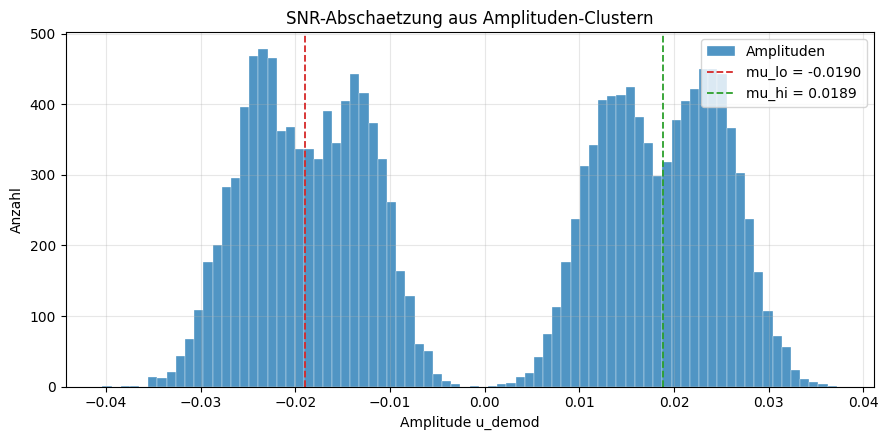

HIST_SYMBOL_CENTER_ONLY=True, N=16383, BIT_START_OFFSET_SAMPLES=39
mu_lo=-0.01897, mu_hi=0.01888, d=0.03785
sigma_lo=0.00630, sigma_hi=0.00633, sigma_pooled=0.00632
SNR_lin ~ 8.977, SNR_dB ~ 9.53 dB


In [89]:
# SNR-Grobschaetzung aus Histogramm-Daten (k=2 Cluster in 1D)
BITRATE_ASSUMED_HZ = 4000.0
SAMPLES_PER_BIT = max(1, int(round(fs / BITRATE_ASSUMED_HZ)))

HIST_SYMBOL_CENTER_ONLY = bool(globals().get("HIST_SYMBOL_CENTER_ONLY", True))
BIT_START_OFFSET_SAMPLES = int(globals().get("BIT_START_OFFSET_SAMPLES", 0))

N_sig = u_demod.size
if HIST_SYMBOL_CENTER_ONLY:
    spb = max(SAMPLES_PER_BIT, 1)
    off = int(BIT_START_OFFSET_SAMPLES) % spb
    first_center = off + spb // 2
    if first_center < 0 or first_center >= N_sig:
        raise RuntimeError("BIT_START_OFFSET_SAMPLES ungueltig fuer SNR-Zelle.")
    n_bits = (N_sig - 1 - first_center) // spb + 1
    if n_bits < 2:
        raise RuntimeError("Zu wenig Daten fuer SNR-Schaetzung - Bitrate/SAMPLES_PER_BIT/BIT_START_OFFSET pruefen.")
    sample_idx = first_center + np.arange(n_bits) * spb
    sample_idx = np.clip(sample_idx, 0, N_sig - 1)
    u_snr = u_demod[sample_idx].astype(np.float64)
else:
    u_snr = u_demod.astype(np.float64)

def kmeans_1d_k2(x: np.ndarray, max_iter: int = 80):
    x = np.asarray(x, dtype=np.float64).ravel()
    c0, c1 = np.percentile(x, [25.0, 75.0])
    if c0 >= c1:
        c0, c1 = float(np.min(x)), float(np.max(x))
    c = np.array([c0, c1], dtype=np.float64)

    for _ in range(max_iter):
        lbl = np.abs(x - c[0]) <= np.abs(x - c[1])
        if np.all(lbl) or np.all(~lbl):
            break
        new_c = np.array([x[lbl].mean(), x[~lbl].mean()], dtype=np.float64)
        if np.max(np.abs(new_c - c)) < 1e-12 * (np.max(np.abs(c)) + 1.0):
            c = new_c
            break
        c = new_c

    lbl = np.abs(x - c[0]) <= np.abs(x - c[1])
    return c, lbl


centers, lbl = kmeans_1d_k2(u_snr)
order = np.argsort(centers)
mu_lo = float(centers[order[0]])
mu_hi = float(centers[order[1]])

# Labels nach sortierten Zentren neu bestimmen
lbl_lo = np.abs(u_snr - mu_lo) <= np.abs(u_snr - mu_hi)

sigma_lo = float(np.std(u_snr[lbl_lo], ddof=1)) if np.sum(lbl_lo) > 1 else 0.0
sigma_hi = float(np.std(u_snr[~lbl_lo], ddof=1)) if np.sum(~lbl_lo) > 1 else 0.0
sigma = float(np.sqrt((sigma_lo**2 + sigma_hi**2) / 2.0 + 1e-30))

d = abs(mu_hi - mu_lo)
snr_lin = (d * d) / (4.0 * sigma * sigma + 1e-30)
snr_db = 10.0 * np.log10(max(snr_lin, 1e-30))

fig, ax = plt.subplots(figsize=(9.0, 4.5))
ax.hist(u_snr, bins=80, color="C0", alpha=0.78, edgecolor="white", linewidth=0.3, label="Amplituden")
ax.axvline(mu_lo, color="C3", ls="--", lw=1.3, label=f"mu_lo = {mu_lo:.4f}")
ax.axvline(mu_hi, color="C2", ls="--", lw=1.3, label=f"mu_hi = {mu_hi:.4f}")
ax.set_title("SNR-Abschaetzung aus Amplituden-Clustern")
ax.set_xlabel("Amplitude u_demod")
ax.set_ylabel("Anzahl")
ax.grid(True, alpha=0.3)
ax.legend(loc="upper right")
plt.tight_layout()
plt.show()

print(
    f"HIST_SYMBOL_CENTER_ONLY={HIST_SYMBOL_CENTER_ONLY}, N={u_snr.size}, BIT_START_OFFSET_SAMPLES={BIT_START_OFFSET_SAMPLES}\n"
    f"mu_lo={mu_lo:.5f}, mu_hi={mu_hi:.5f}, d={d:.5f}\n"
    f"sigma_lo={sigma_lo:.5f}, sigma_hi={sigma_hi:.5f}, sigma_pooled={sigma:.5f}\n"
    f"SNR_lin ~ {snr_lin:.3f}, SNR_dB ~ {snr_db:.2f} dB"
)


## 6) Audiofeedback

In [86]:
# Audio-Resampling auf 48kHz Abtastrate
if fs != fs_audio:
    t_src = np.arange(len(u_demod)) / fs
    n_dst = int(len(u_demod) * fs_audio / fs)
    t_dst = np.arange(n_dst) / fs_audio
    x_audio_full = np.interp(t_dst, t_src, u_demod)
else:
    x_audio_full = u_demod.copy()

max_start_s = max(0.0, (len(x_audio_full) - 1) / fs_audio)
start_s_eff = min(max(float(start_s), 0.0), max_start_s)
if start_s_eff != float(start_s):
    print(f'Hinweis: start_s={start_s:.2f} s liegt außerhalb. Verwende start_s={start_s_eff:.2f} s.')

start_idx = int(start_s_eff * fs_audio)
x_audio_seg = x_audio_full[start_idx:]
target_len = int(duration_s * fs_audio)
rep = max(1, int(np.ceil(target_len / len(x_audio_seg))))
x_audio = np.tile(x_audio_seg, rep)[:target_len]
x_audio = x_audio / max(np.max(np.abs(x_audio)), 1e-12)

print(f'Audio vorbereitet: Start={start_s_eff:.2f} s, {len(x_audio)} Samples @ {fs_audio} Hz, Dauer {len(x_audio)/fs_audio:.2f} s')
display(Audio(x_audio, rate=fs_audio))

Audio vorbereitet: Start=0.00 s, 240000 Samples @ 48000 Hz, Dauer 5.00 s


## ToDo: Analysen und Dokumentation

1. Erstelle ein Blockschaltbild vom gesamten Signalpfad, beginnend mit Sender, Funkstrecke, SDR, und alle hier im Notebook implementierten Signalverarbeitungsstufen, pro Block im Text HIER eine kurze und prägnante Beschreibung der mathematischen Operationen (z.B. FIR-Filter, Frequenzverschiebung, Funktionsweise der FM-Demodulation, Histogram-Analyse, Augendiagramm, etc.)
2. Welche Relevanz haben Augendiagramm und Amplituden-Histogramm? Was können wir daraus ablesen, wie hängt die erzielte Bitfehler-Rate damit zusammen?
   

## ToDo: Blockdiagramm der Signalverarbeitungs-Stufen von Sender, Funkstrecke bis zum demodulierten Datenstrom HIER einfügen

- Syntax für Link zum Blockdiagramm![erklärender Text](media\bild.jpg)
  

## ToDo: Analyse:

- Ermittle den Zusammenhang zwischen FIR-Tiefpassfilter-Bandbreite und erzieltem SNR nach der Demodulation für cutoff-Frequenzen bis 50 kHz.
- Stelle das Ergebnis in Tabellenform oder Plot dar.
- Ermittle die optimale Filterbandbreite für maximales SNR.
- Ermittle den optimalen Abtastzeitpunkt mit Hilfe des Amplitudenhistogramms (Slidereinstellung)
  